# ViT W4/W8 module-sensitivity heatmap from Notebook 22

Notebook 22 saves cross-bit scatter plots and an accuracy/compression plot, but no heatmap. This follow-up visualizes its **existing measured results** as a seven-module, four-column heatmap.

**Source:** `artifacts/vit_4bit_stratified_sensitivity/stratified_module_w4_vs_w8.csv`, saved by Notebook 22, cell 13 (zero-based). Its W4 results are joined to the matching W8 results from Notebook 19. Every isolated evaluation uses the complete 10,000-image CIFAR-10 test split, with all other modules left FP32.

Run all cells using the project's `.venv` kernel. Only NumPy, pandas, Matplotlib and IPython are needed. This notebook reads saved CSVs; it performs no model loading, training, quantization, downloads or inference. Output files go to `artifacts/vit_w4_w8_heatmap/`, leaving Notebook 22's results untouched.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "notebooks").is_dir() and (path / "src").is_dir()
)
SOURCE_NOTEBOOK = PROJECT_ROOT / "notebooks" / "22_vit_cifar10_4bit_stratified_sensitivity_w4_w8.ipynb"
SOURCE_CSV = PROJECT_ROOT / "artifacts" / "vit_4bit_stratified_sensitivity" / "stratified_module_w4_vs_w8.csv"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "vit_w4_w8_heatmap"
FIGURE_PATH = OUTPUT_DIR / "vit_w4_w8_module_sensitivity_heatmap.png"
PDF_PATH = FIGURE_PATH.with_suffix(".pdf")
VALUES_PATH = OUTPUT_DIR / "vit_w4_w8_heatmap_values.csv"
MANIFEST_PATH = OUTPUT_DIR / "heatmap_manifest.json"

# The predefined architectural order from Notebook 22, cell 3.
STRATIFIED_MODULES = (
    "input_embedding", "transformer_block_1", "transformer_block_3",
    "transformer_block_6", "transformer_block_9", "transformer_block_11", "classifier",
)
COLUMN_SPECS = (("ptq", "w4"), ("ptq", "w8"), ("codebook", "w4"), ("codebook", "w8"))
COLUMN_LABELS = ["PTQ W4", "PTQ W8", "Codebook W4", "Codebook W8"]
if not SOURCE_CSV.is_file():
    raise FileNotFoundError(f"Run Notebook 22 through its matched W4/W8 comparison first: {SOURCE_CSV}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Reading saved Notebook 22 results: {SOURCE_CSV.relative_to(PROJECT_ROOT)}")

Reading saved Notebook 22 results: artifacts/vit_4bit_stratified_sensitivity/stratified_module_w4_vs_w8.csv


## Validate and arrange the measured results

Require exactly one record per method and sampled module. Check that saved degradation agrees with FP32 accuracy minus quantized accuracy at both precisions. Preserve Notebook 22's architectural selection order; do not sort by sensitivity or fill missing measurements.

Each cell is accuracy degradation in percentage points: **positive = loss**, **negative = observed gain**. Full-precision values are exported separately; the heatmap uses color-only cells, matching Notebooks 20 and 21.

In [2]:
source_sha256 = hashlib.sha256(SOURCE_CSV.read_bytes()).hexdigest()
comparison = pd.read_csv(SOURCE_CSV)
required = {"method_family", "module", "module_index", "fp32_accuracy_percent"}
for bit in ("w4", "w8"):
    required.update({f"quantized_accuracy_percent_{bit}", f"accuracy_degradation_pp_{bit}"})
assert required.issubset(comparison.columns), f"Missing columns: {required - set(comparison.columns)}"
assert len(comparison) == 14
assert set(comparison.method_family) == {"ptq", "codebook"}
assert not comparison.duplicated(["method_family", "module"]).any()
for family in ("ptq", "codebook"):
    group = comparison[comparison.method_family.eq(family)].sort_values("module_index")
    assert tuple(group.module) == STRATIFIED_MODULES
    assert group.module_index.tolist() == list(range(7))
for bit in ("w4", "w8"):
    numeric = comparison[["fp32_accuracy_percent", f"quantized_accuracy_percent_{bit}", f"accuracy_degradation_pp_{bit}"]]
    assert np.isfinite(numeric.to_numpy()).all()
    np.testing.assert_allclose(
        comparison[f"accuracy_degradation_pp_{bit}"],
        comparison.fp32_accuracy_percent - comparison[f"quantized_accuracy_percent_{bit}"],
        rtol=0, atol=1e-10,
    )
heatmap = pd.DataFrame(index=pd.Index(STRATIFIED_MODULES, name="module"))
for family, bit in COLUMN_SPECS:
    group = comparison[comparison.method_family.eq(family)].set_index("module")
    heatmap[f"{family}_{bit}"] = group.loc[list(STRATIFIED_MODULES), f"accuracy_degradation_pp_{bit}"]
assert heatmap.shape == (7, 4) and np.isfinite(heatmap.to_numpy()).all()
heatmap.to_csv(VALUES_PATH, float_format="%.17g")
print("Validated 14 matched records and 28 heatmap values.")
display(heatmap)

Validated 14 matched records and 28 heatmap values.


,ptq_w4,ptq_w8,codebook_w4,codebook_w8
module,,,,
input_embedding,-0.18,-0.02,-0.18,0.00
transformer_block_1,-0.15,-0.01,0.20,-0.06
transformer_block_3,0.03,-0.02,-0.05,0.03
transformer_block_6,0.04,-0.02,0.05,0.06
transformer_block_9,-0.01,-0.06,0.02,-0.05
transformer_block_11,0.02,-0.05,0.00,-0.04
classifier,0.01,-0.02,-0.07,-0.03


## Generate the heatmap

Use the same 10 × 9 inch figure, color-only cells, column labels and vertical color bar as the report heatmaps in Notebooks 20 and 21. All three use `TwoSlopeNorm` with zero at the neutral midpoint: red denotes loss and blue an observed gain. DistilBERT and ViT share a symmetric ±0.35-pp scale; ResNet uses ±80 pp. Compare numeric color-bar values across different scales. Module order remains the predefined architectural order from Notebook 22.

The PNG displayed below is the same file copied into the report; a vector PDF is also saved.

Saved: artifacts/vit_w4_w8_heatmap/vit_w4_w8_module_sensitivity_heatmap.png


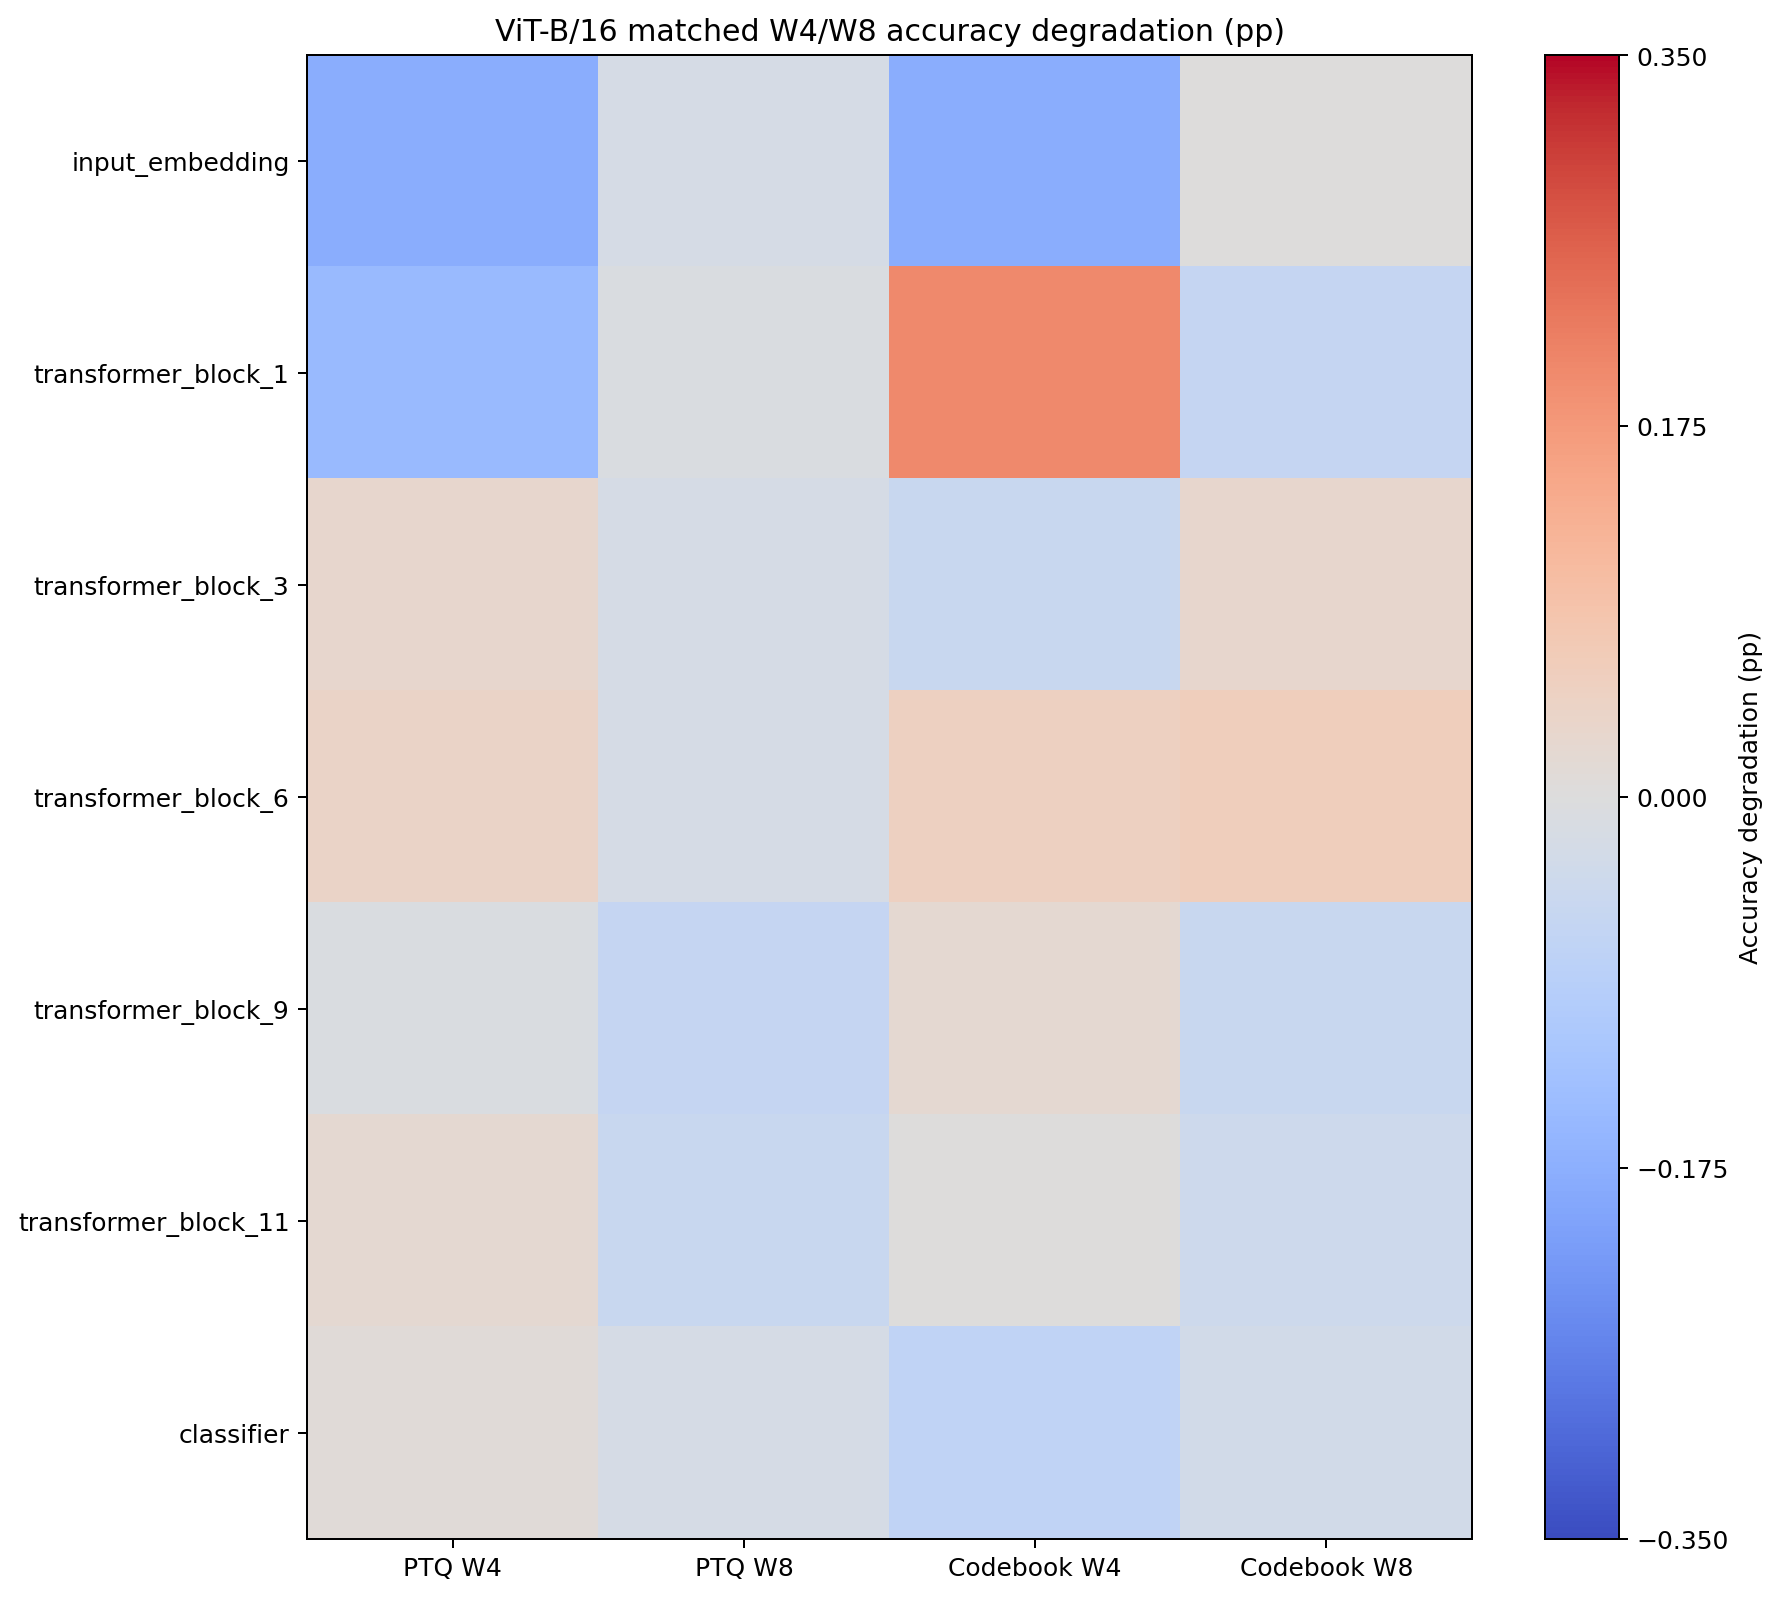

In [3]:
values = heatmap.to_numpy()
color_bound = 0.35
assert np.abs(values).max() <= color_bound
with plt.rc_context({"pdf.fonttype": 42}):
    fig, axis = plt.subplots(figsize=(10, 9))
    image = axis.imshow(values, aspect="auto", cmap="coolwarm",
                        norm=TwoSlopeNorm(vmin=-color_bound, vcenter=0, vmax=color_bound))
    axis.set_xticks(range(4), COLUMN_LABELS)
    axis.set_yticks(range(len(heatmap)), heatmap.index)
    axis.set_title("ViT-B/16 matched W4/W8 accuracy degradation (pp)")
    fig.colorbar(image, ax=axis, label="Accuracy degradation (pp)",
                 ticks=np.linspace(-color_bound, color_bound, 5))
    fig.tight_layout()
    fig.savefig(FIGURE_PATH, dpi=180, bbox_inches="tight")
    fig.savefig(PDF_PATH, bbox_inches="tight")
    color_limits = [float(value) for value in image.get_clim()]
    plt.close(fig)
display(Image(filename=str(FIGURE_PATH)))
print(f"Saved: {FIGURE_PATH.relative_to(PROJECT_ROOT)}")

## Record provenance

The manifest records the source CSV checksum, source notebook, module/column ordering, scale, software versions and output checksums. Notebook 22's original artifacts are read-only inputs.

In [4]:
assert hashlib.sha256(SOURCE_CSV.read_bytes()).hexdigest() == source_sha256
manifest = {
    "generated_by": "notebooks/27_vit_w4_w8_sensitivity_heatmap_from_notebook22.ipynb",
    "source_notebook": str(SOURCE_NOTEBOOK.relative_to(PROJECT_ROOT)),
    "source_csv": str(SOURCE_CSV.relative_to(PROJECT_ROOT)),
    "source_csv_sha256": source_sha256,
    "source_plot_data_cell_index": 13,
    "module_order": list(STRATIFIED_MODULES),
    "column_order": list(heatmap.columns),
    "metric": "FP32 accuracy minus isolated quantized accuracy, in percentage points",
    "coverage": {"sampled_modules": 7, "total_modules": 14, "test_examples": 10000},
    "color_scale_pp": color_limits,
    "color_normalization": "TwoSlopeNorm, zero-centered, symmetric bounds",
    "color_center_pp": 0,
    "shared_scale_with": "DistilBERT (Notebook 21)",
    "cell_annotations": False,
    "figure_size_inches": [10, 9],
    "png_dpi": 180,
    "style_reference_notebooks": [20, 21],
    "inference_rerun": False,
    "software": {"python": sys.version.split()[0], "numpy": np.__version__,
                 "pandas": pd.__version__, "matplotlib": matplotlib.__version__},
    "outputs": [{"path": str(path.relative_to(PROJECT_ROOT)),
                 "sha256": hashlib.sha256(path.read_bytes()).hexdigest()}
                for path in (FIGURE_PATH, PDF_PATH, VALUES_PATH)],
}
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2) + "\n")
print(f"Saved provenance: {MANIFEST_PATH.relative_to(PROJECT_ROOT)}")

Saved provenance: artifacts/vit_w4_w8_heatmap/heatmap_manifest.json


## Interpretation

- The heatmap covers the same seven predefined modules as Notebook 22, **not all 14 ViT modules**.
- Positive values indicate accuracy loss from quantizing one module while all other modules remain FP32. Negative values are observed accuracy gains, not evidence of better generalization.
- The current measurements show a largest isolated W4 loss of 0.20 pp for codebook quantization of `transformer_block_1`; the largest PTQ W4 loss is 0.04 pp at `transformer_block_6`.
- ViT and DistilBERT share a ±0.35-pp scale; ResNet uses ±80 pp. Compare numeric color-bar values across those different scales.
- This visualization introduces no new accuracy measurements and does not change Notebook 22's statistical conclusions. It does not measure full-model interactions or native low-bit runtime performance.